In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load the same clean dataset
df = pd.read_csv("../data/mexico-real-estate-clean.csv")

print("✅ Clean data loaded for modeling!")
print("Shape:", df.shape)
df.head()

✅ Clean data loaded for modeling!
Shape: (1978, 6)


,property_type,state,lat,lon,area_m2,price_usd
0,house,Estado de México,19.560181,-99.233528,150,67965.56
1,house,Nuevo León,25.688436,-100.198807,186,63223.78
2,apartment,Guerrero,16.767704,-99.764383,82,84298.37
3,apartment,Guerrero,16.829782,-99.911012,150,94308.80
4,house,Yucatán,21.052583,-89.538639,205,105191.37


In [2]:
# We need to convert 'state' (text) into numbers
# Because models only understand numbers!
df_model = df.copy()

# This creates a column for each state with 0 or 1
df_model = pd.get_dummies(df_model, columns=["state", "property_type"])

# Our target (what we want to predict)
y = df_model["price_usd"]

# Our features (what we use to predict)
# Drop the target and non-numeric columns
X = df_model.drop(columns=["price_usd"])

# Drop lat/lon for now (using state instead for location)
X = X.drop(columns=["lat", "lon"], errors="ignore")

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", X.columns.tolist()[:10], "...")

Features shape: (1978, 31)
Target shape: (1978,)

Feature columns: ['area_m2', 'state_Aguascalientes', 'state_Baja California', 'state_Baja California Sur', 'state_Chiapas', 'state_Chihuahua', 'state_Colima', 'state_Distrito Federal', 'state_Durango', 'state_Estado de México'] ...


In [3]:
# 80% of data trains the model, 20% tests how good it is
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {len(X_train):,}")
print(f"Testing rows:  {len(X_test):,}")

Training rows: 1,582
Testing rows:  396


In [4]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [5]:
# Make predictions on the hidden test data
y_pred = model.predict(X_test)

# Calculate accuracy metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== MODEL PERFORMANCE ===")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R² Score: {r2:.4f} ({r2*100:.1f}%)")
print()
print("What this means:")
print(f"→ On average, predictions are off by ${mae:,.2f}")
print(f"→ The model explains {r2*100:.1f}% of price variation")

=== MODEL PERFORMANCE ===
Mean Absolute Error: $35,363.56
R² Score: 0.5186 (51.9%)

What this means:
→ On average, predictions are off by $35,363.56
→ The model explains 51.9% of price variation


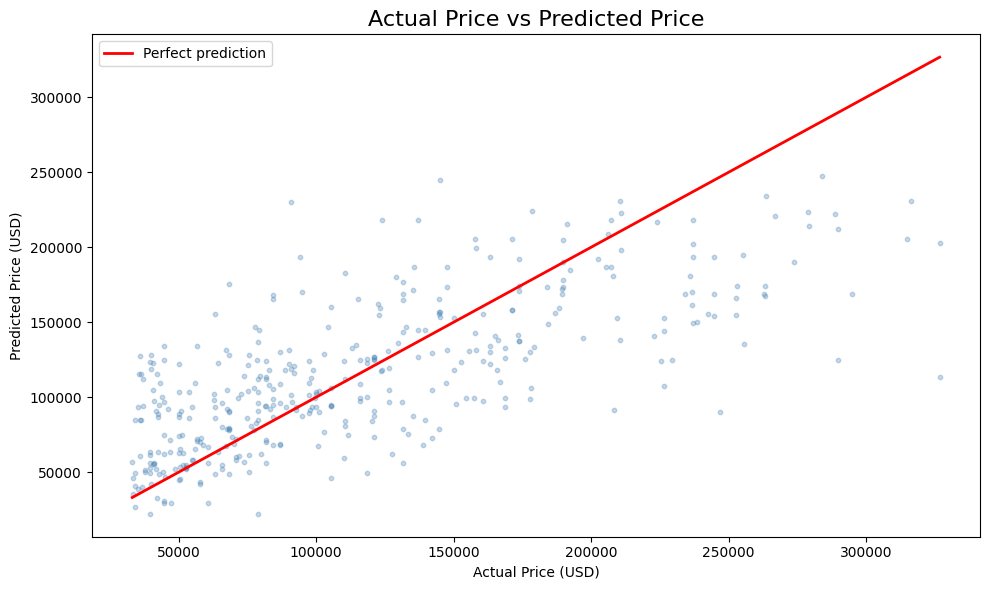

In [6]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=10)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red", linewidth=2, label="Perfect prediction"
)

plt.title("Actual Price vs Predicted Price", fontsize=16)
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.legend()
plt.tight_layout()
plt.savefig("../notebooks/predictions_vs_actual.png")
plt.show()

In [7]:
# Let's predict a specific house price
# Create a sample with all the same columns as X_train
sample = pd.DataFrame(0, index=[0], columns=X_train.columns)

# Fill in the details of our imaginary house
sample["area_m2"] = 150          # 150 square meters
if "state_Puebla" in sample.columns:
    sample["state_Puebla"] = 1   # located in Puebla
if "property_type_house" in sample.columns:
    sample["property_type_house"] = 1  # it's a house

predicted_price = model.predict(sample)[0]
print(f"🏠 Predicted price for a 150m² house in Puebla:")
print(f"   ${predicted_price:,.2f} USD")


🏠 Predicted price for a 150m² house in Puebla:
   $92,770.30 USD
